## A short notebook tutorial on Gaussian Process Regression w/ GPy package

*Last Modified*: July 24th, 2024

Author: [Opal Issan](https://opaliss.github.io/opalissan/) (PhD student @UCSD). contact: oissan@ucsd.edu

In [1]:
import sys, os

sys.path.append(os.path.abspath(os.path.join("..")))

In [2]:
import numpy as np
import scipy
import GPy
from IPython.display import display

In [4]:
import matplotlib.pyplot as plt
import matplotlib
from mycolorpy import colorlist as mcp

font = {"family": "serif", "size": 14}

matplotlib.rc("font", **font)
matplotlib.rc("xtick", labelsize=14)
matplotlib.rc("ytick", labelsize=14)

## 1D Regression Example

In [5]:
# artificial random data
X = np.random.uniform(-3.0, 3.0, (20, 1))
Y = np.sin(X) + np.random.randn(20, 1) * 0.05

In [6]:
# setup kernel + its hyperparameters
kernel = GPy.kern.RBF(input_dim=1)

In [7]:
# solve the regression problem
model = GPy.models.GPRegression(X, Y, kernel)

In [8]:
# print the GP hyperparameters
display(model)

GP_regression.,value,constraints,priors
rbf.variance,1.0,+ve,
rbf.lengthscale,1.0,+ve,
Gaussian_noise.variance,1.0,+ve,


In [9]:
X_pred = np.reshape(np.linspace(-4, 4, 100), (100, 1))
A, B = model.predict(Xnew=X_pred)

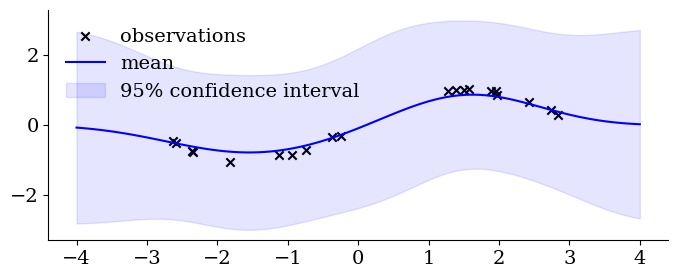

In [10]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(X, Y, marker="x", color="black", label="observations")
ax.plot(X_pred, A, color="blue", label="mean")
ax.fill_between(
    np.reshape(np.linspace(-4, 4, 100), (100, 1))[:, 0],
    (A - 2 * np.sqrt(B))[:, 0],
    (A + 2 * np.sqrt(B))[:, 0],
    color="b",
    alpha=0.1,
    label="95% confidence interval",
)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

legend = ax.legend()
legend.get_frame().set_alpha(0)
plt.tight_layout()

The default values of the kernel parameters may not be optimal for the current data. A common approach is to find the values of the parameters that **maximize the likelihood of the data**. It as easy as calling *optimize* in GPy.

In [11]:
# optimize the hyperparameters
model.optimize(messages=True)

Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s01  0002   1.717647e+01   3.899900e+01 
    00s03  0007  -5.772961e+00   1.848635e+02 
    00s05  0011  -1.873417e+01   1.818228e+00 
    00s07  0017  -1.880456e+01   1.836498e-09 
    00s07  0019  -1.880456e+01   6.235535e-13 
Runtime:     00s07
Optimization status: Converged



In [12]:
display(model)

GP_regression.,value,constraints,priors
rbf.variance,0.7098576811940039,+ve,
rbf.lengthscale,1.4278667963017335,+ve,
Gaussian_noise.variance,0.0012826278071230992,+ve,


In [13]:
X_pred = np.reshape(np.linspace(-4, 4, 100), (100, 1))
A, B = model.predict(Xnew=X_pred)

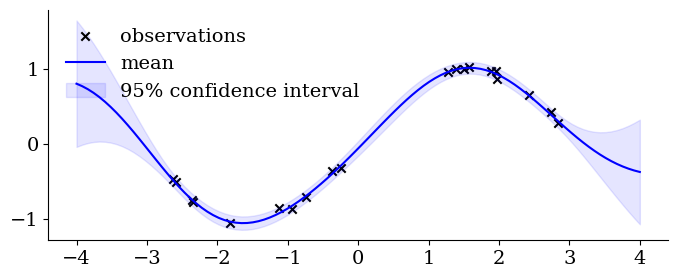

In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(X, Y, marker="x", color="black", label="observations")
ax.plot(X_pred, A, color="blue", label="mean")
ax.fill_between(
    np.reshape(np.linspace(-4, 4, 100), (100, 1))[:, 0],
    (A - 2 * np.sqrt(B))[:, 0],
    (A + 2 * np.sqrt(B))[:, 0],
    color="b",
    alpha=0.1,
    label="95% confidence interval",
)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

legend = ax.legend()
legend.get_frame().set_alpha(0)
plt.tight_layout()

## 2D Regression Example

In [15]:
# sample inputs and outputs
X = np.random.uniform(-3.0, 3.0, (50, 2))
Y = np.sin(X[:, 0:1]) * np.sin(X[:, 1:2]) + np.random.randn(50, 1) * 0.05

In [16]:
# setup kernel + its hyperparameters
kernel = GPy.kern.RBF(input_dim=2, variance=1.0, lengthscale=1.0)

In [17]:
# create simple GP model
m = GPy.models.GPRegression(X, Y, kernel)
# optimize
m.optimize(messages=True, max_f_eval=1000)

Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s03  0008   4.977976e+01   1.226799e+03 
    00s05  0012  -3.164808e+01   3.289228e-01 
    00s07  0020  -3.166387e+01   2.567201e-10 
Runtime:     00s07
Optimization status: Converged



In [18]:
# location of prediction mesh grid
N_pred = 1000
XX, YY = np.meshgrid(np.linspace(-3, 3, N_pred), np.linspace(-3, 3, N_pred))

In [19]:
A, B = m.predict(
    Xnew=np.array([np.ndarray.flatten(XX, "C"), np.ndarray.flatten(YY, "C")]).T
)

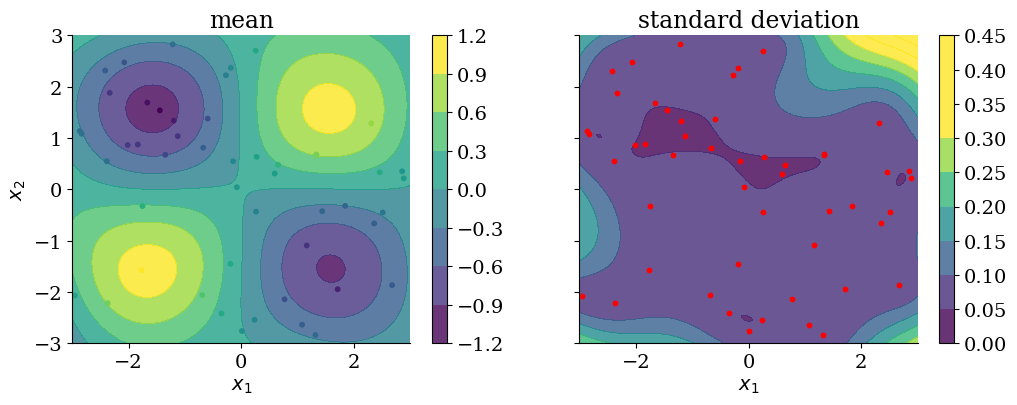

In [20]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
ax[0].spines["right"].set_visible(False)
ax[0].spines["top"].set_visible(False)
_ = ax[0].set_xlabel("$x_{1}$")
_ = ax[0].set_ylabel("$x_{2}$")
pos = ax[0].contourf(
    XX, YY, np.reshape(A, (N_pred, N_pred)), alpha=0.8, vmin=np.min(Y), vmax=np.max(Y)
)
cbar = fig.colorbar(pos, orientation="vertical")
_ = ax[0].scatter(
    X[:, 0], X[:, 1], c=Y, s=10, cmap="viridis", vmin=np.min(Y), vmax=np.max(Y)
)
_ = ax[0].set_title("mean")

ax[1].spines["right"].set_visible(False)
ax[1].spines["top"].set_visible(False)
_ = ax[1].set_xlabel("$x_{1}$")
pos = ax[1].contourf(
    XX, YY, np.reshape(np.sqrt(B), (N_pred, N_pred)), alpha=0.8, vmin=0.04, vmax=0.32
)
cbar = fig.colorbar(pos, orientation="vertical")
_ = ax[1].scatter(X[:, 0], X[:, 1], c="red", s=10)
_ = ax[1].set_title("standard deviation")